# Exercises Chapter 3

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [2]:
import statsmodels.api as sm

In [3]:
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [4]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize ,
poly)

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
print("test, are we done?")

test, are we done?


## Conceptual

### 1.
Describe the null hypotheses to which the p-values given in Table 3.4
correspond. Explain what conclusions you can draw based on these
p-values. Your explanation should be phrased in terms of sales, TV,
radio, and newspaper, rather than in terms of the coefficients of the
linear model.

<img src="images_for_notes/Chapter3_tab3_4.png" width="700">




<span style="color:blue"> The p value represents the probability that, given the Null Hypothesis that the true value of the coefficient were actually 0, we would get a result with a t-statistic at least as high as the one we got. In the case of p-value <0.0001, it means that if we assume the true value of coefficient was 0, the odds that we would get an estimated coefficient of (*whatever we got*) is less than 0.0001. In the case of newspaper, it means if we assume that Units sold = Intercept + TV * 0.046 + Radio * 0.189 + 0 * Newspaper, the odds that the t statistic for newspaper would be this high would be 0.8599, i.e. very likely.</span>


#### 2.
(page 137 rn) Carefully explain the differences between the KNN classifier and KNN
regression methods.

<span style="color:blue"> The KNN classifier is a system which decides what value X should have given its K nearest neighbors. K can be changed to increase or decrease flexibility, with lower K corresponding to more flexibility. The way the system works is it looks at the K nearest neighbors, and assigns the value of Y with the highest frequency within these K nearest neighbors. </span>

<span style="color:blue"> On the other hand, KNN regression is a different method which also looks at the K nearest neighbors, but instead of picking the category with the highest rate of occurence (as its a regression problem), it takes the average of the K nearest values and uses that as its output.</span>

#### 3.
Suppose we have a data set with five predictors,

$X_1 =$ GPA, $X_2$ = IQ, $X_3$ = Level (1 for College and 0 for High School), $X_4$ = Interaction
between GPA and IQ, and $X5$ = Interaction between GPA and
Level. 

The response is starting salary after graduation (in thousands
of dollars). Suppose we use least squares to fit the model, and get
$\hat{\beta_0} = 50, \hat{\beta_1} = 20, \hat{\beta_2} = 0.07, \hat{\beta_3} = 35, \hat{\beta_4} = 0.01, \hat{\beta_5} = −10.$

a) Which answer is correct, and why?
    
    i. For a fixed value of IQ and GPA, high school graduates earn
    more, on average, than college graduates.
    ii. For a fixed value of IQ and GPA, college graduates earn
    more, on average, than high school graduates.
    iii. For a fixed value of IQ and GPA, high school graduates earn
    more, on average, than college graduates provided that the
    GPA is high enough.
    iv. For a fixed value of IQ and GPA, college graduates earn
    more, on average, than high school graduates provided that
    the GPA is high enough.

<span style="color:blue"> The correct answer is if GPA is high enough, for fixed value of IQ and GPA, high school graduates make more on average than college graduates</span>

b) Predict the salary of a college graduate with IQ of 110 and a
GPA of 4.0.

In [8]:
gpa_123 = 4
iq_123 = 110

test_123 = 50 + 20*gpa_123 + 0.07*iq_123 + 35 + 0.01*(iq_123*gpa_123) - 10*(gpa_123)

test_123

137.1

(c) True or false: Since the coefficient for the GPA/IQ interaction
term is very small, there is very little evidence of an interaction
effect. Justify your answer.

<span style="color:blue"> I'd say false, as though the interaction is small, we don't know the p-value, the p-value could be very high due to a high t-statistic / F-Statistic.</span>





#### 4. 
I collect a set of data (n = 100 observations) containing a single
predictor and a quantitative response. I then fit a linear regression
model to the data, as well as a separate cubic regression, i.e. 

$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3X^3 + \epsilon$

(a) Suppose that the true relationship between X and Y is linear,
i.e. 

$Y = \beta_0 + \beta_1X + \epsilon$

Consider the training residual sum of squares (RSS) for the linear regression, and also the training
RSS for the cubic regression. Would we expect one to be lower
than the other, would we expect them to be the same, or is there
not enough information to tell? Justify your answer.

<span style="color:blue"> We would expect the training for cubic regression to be higher on the training data, but lower on the test data. Increasing the flexibility of the model *always* lowers RSS on it, as at worst it will just set the quadratic and cubis terms (in this case) to be zero, and the model will be just as good. This however doesnt mean its a better model, it will suffer some degree of overfitting (since we know its really just linear). </span>

(b) Answer (a) using test rather than training RSS

<span style="color:blue"> As said before, the Test RSS would likely be smaller in the linear approximation than the cubic one.</span>

(c) Suppose that the true relationship between X and Y is not linear,
but we don’t know how far it is from linear. Consider the training
RSS for the linear regression, and also the training RSS for the
cubic regression. Would we expect one to be lower than the
other, would we expect them to be the same, or is there not
enough information to tell? Justify your answer.

<span style="color:blue"> The cubic will always have an RSS thats lower (or at least just as good) than the linear OLS estimation.</span>

(d) Answer (c) using test rather than training RSS.

<span style="color:blue"> Its impossible to say for sure. If it were close to linear, I'd expect the RSS on the test to be lower with the linear approximation, but if its far from linear, I'd expect the cubic approximation to do better, even though I could see this failing under weird circumstances.</span>


### 5. 
Consider the fitted values that result from performing linear regression
without an intercept. In this setting, the ith fitted value takes
the form

$\hspace{100pt} \hat{y_i} = x_i \hat{\beta},$

where

$\hspace{100pt} \hat{\beta} = \left( \sum^n_{i=1} x_i y_i \right)  / \left( \sum^n_{i^{'} = 1} x_{i^{'}}^2 \right)  \hspace{70pt} (3.38)$

Show that we can write 

$\hspace{100pt} \hat{y_i} = \sum_{i^{'} = 1}^n a_{i^{'}} y_{i_{'}}$

What is $a_{i^{'}}$?

<span style="color:blue">We got it irl so leaving this unwritten (basically sub, expand and reorder) </span>

#### 6.
Using (3.4), argue that in the case of simple linear regression, the
least squares line always passes through the point ( $\overline{x}, \overline{y}$ ).

<span style="color:blue"> Ok so the textbook says that these are the minimizers. </span>

<img src="images_for_notes/Chapter3_eq3_4.png" width="700">

<span style="color:blue">Plug in and reorder. Done in book </span>


# Applied

#### 8. This question involves the use of simple linear regression on the *Auto* data set.

(a) Use the sm.OLS() function to perform a simple linear regression with *mpg* as the response and *horsepower* as the predictor. Use the *summarize()* function to print the results. Comment on the output.

In [9]:
Auto = load_data("Auto")
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [10]:
X_8ai = pd.DataFrame({'intercept': np.ones(Auto.shape[0]),
                        'horsepower' : Auto['horsepower']})
X_8ai[:4]

,intercept,horsepower
name,,
chevrolet chevelle malibu,1.0,130
buick skylark 320,1.0,165
plymouth satellite,1.0,150
amc rebel sst,1.0,150


In [11]:
y_8ai = Auto['mpg']

model_8ai = sm.OLS(y_8ai, X_8ai)
results_8ai = model_8ai.fit()

In [12]:
summarize(results_8ai)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


i. Is there a relationship between the predictor and the response?

<span style="color:blue"> It certainly seems to be the case, as the P-value is very small for the hypothesis test that the coef is 0. </span>

ii. How strong is the relationship between the predictor and
the response?

<span style="color:blue"> The actual estimated value of the coefficient is pretty small </span>

iii. Is the relationship between the predictor and the response
positive or negative?

<span style="color:blue"> Its negative, the higher horsepower is, the lower mpg is predicted to be. </span>

iv. What is the predicted mpg associated with a horsepower of
98? What are the associated 95 % confidence and prediction
intervals?

<span style="color:blue"> </span>

In [13]:
# Answer sheet:

prediction_8aiv = results_8ai.get_prediction(pd.DataFrame({'const': [1.0], 'horsepower':[98]}))
prediction_8aiv.predicted_mean

array([24.46707715])

(b) Plot the response and the predictor in a new set of axes ax. Use
the ax.axline() method or the abline() function defined in the
lab to display the least squares regression line.

In [14]:
# Use the function to plot line we used in lab
def abline(ax, b, m, *args , **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim , ylim , *args , **kwargs)

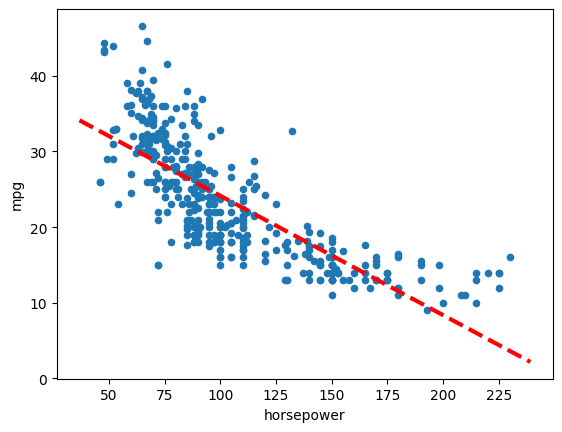

In [15]:
# Input the correct data
ax = Auto.plot.scatter('horsepower', 'mpg')
abline(ax,
    results_8ai.params.iloc[0],
    results_8ai.params.iloc[1],
    'r--',
    linewidth=3)

(c) Produce some of diagnostic plots of the least squares regression
fit as described in the lab. Comment on any problems you see
with the fit.


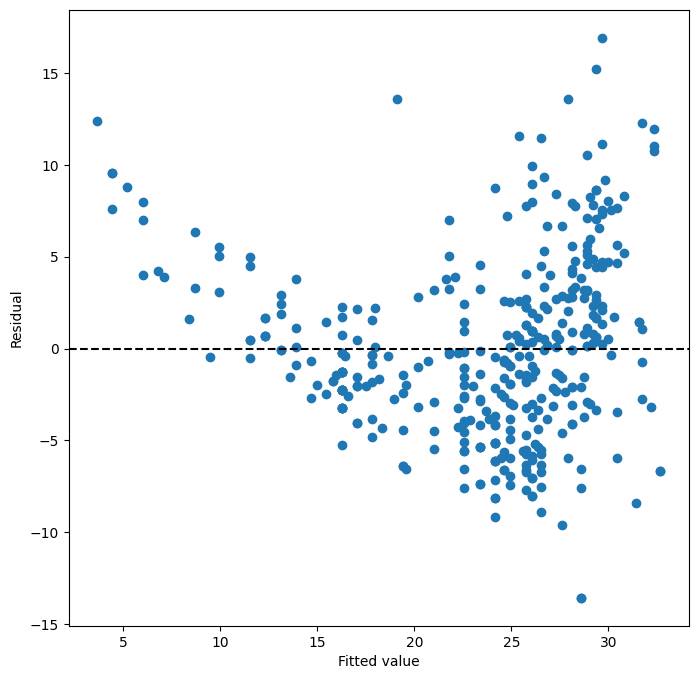

In [16]:
# Ok would be cool to describe all the diagnostic plots tee hee.
# Diagnostic plot 1: Residuals plot:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results_8ai.fittedvalues , results_8ai.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(115)

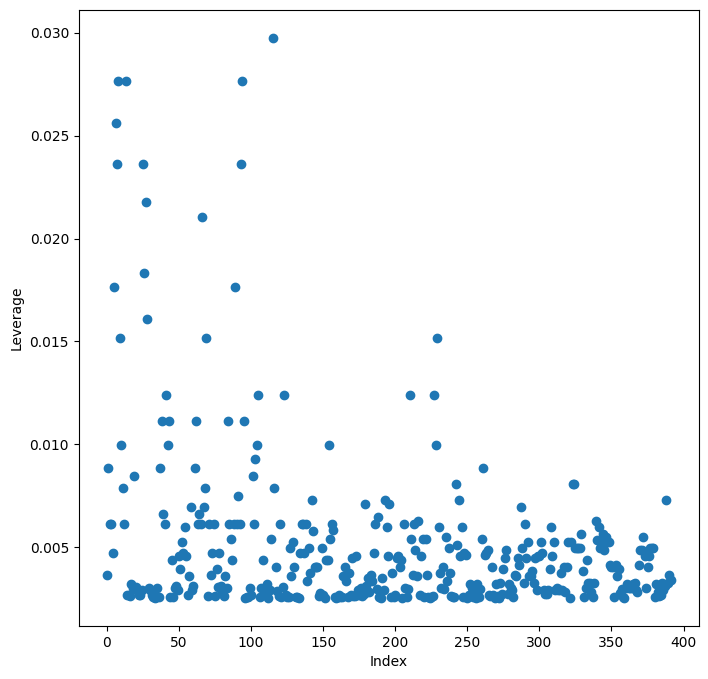

In [17]:
# Now we make a leverage graph
infl_8ai = results_8ai.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X_8ai.shape[0]), infl_8ai.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl_8ai.hat_matrix_diag)

# 9. 
This question involves the use of multiple linear regression on the
Auto data set.

(a) Produce a scatterplot matrix which includes all of the variables
in the data set.

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='horsepower', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement

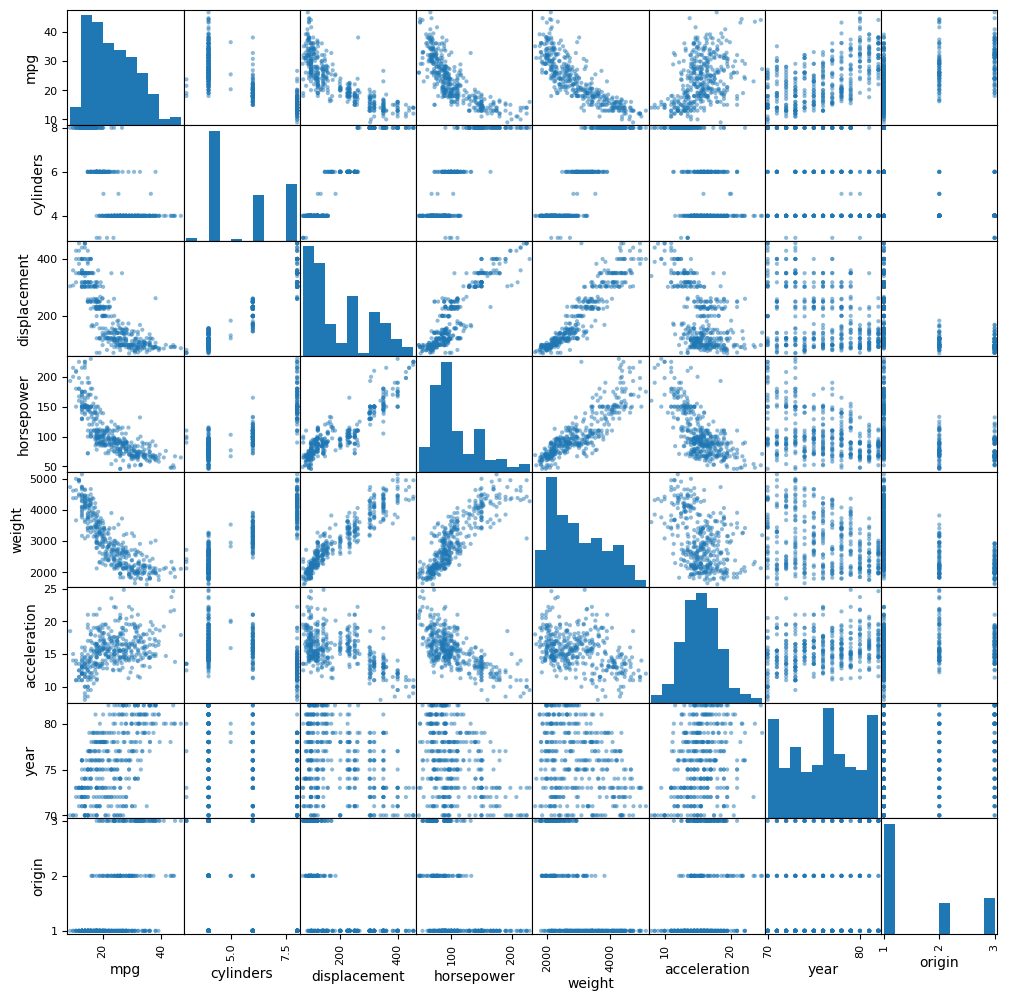

In [18]:
pd.plotting.scatter_matrix(Auto, figsize=(12,12))

(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method.

In [19]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [20]:
# Their answer is a bit prettier:
#sns.heatmap(auto.corr(), annot=True);
#however, we don't have sns 


Use the sm.OLS() function to perform a multiple linear regression
with mpg as the response and all other variables except name as
the predictors. Use the summarize() function to print the results.
Comment on the output. For instance:
    
    i. Is there a relationship between the predictors and the response?
    Use the anova_lm() function from statsmodels to
    answer this question.

In [21]:
#terms = Boston.columns.drop('medv')
#terms

In [22]:
# We set y to equal the response
y = Auto['mpg']

# We drop the response, and the column 'name' as specified in the question
terms = Auto.columns.drop('mpg', 'name')
terms

# We 
X = MS(terms).fit_transform(Auto)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

# Now, to see if there IS a relationship between the predictor vars and the response, we need to make a "only intercept" model sop to speak

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [23]:
X_base = pd.DataFrame({'intercept': np.ones(Auto.shape[0])}, index=Auto.index)

model_base = sm.OLS(y, X_base)
results_base = model_base.fit()

anova_lm(results_base, results)

# Yes, we can see from the F-statistic (and the lower Residual Sum Squared (ssr)) that there is a lot of evidence of a relationship between
# the predictors and the response.

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,391.0,23818.993469,0.0,NaN,NaN,NaN
1,384.0,4252.212530,7.0,19566.780939,252.428045,2.037106e-139


(ii) Which predictors appear to have a statistically significant
relationship to the response?

<span style="color:blue"> The statistically significant ones are the ones with low P-values, ergo here its displacement, weight, year, origin. </span>

(iii.) What does the coefficient for the year variable suggest?

<span style="color:blue"> It suggests that for every increase in year, you would expect to see an increase in mpg of 0.7508</span>

In [24]:
summarize(results)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [25]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          2.04e-139
Time:                        18:16:52   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707   

(d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

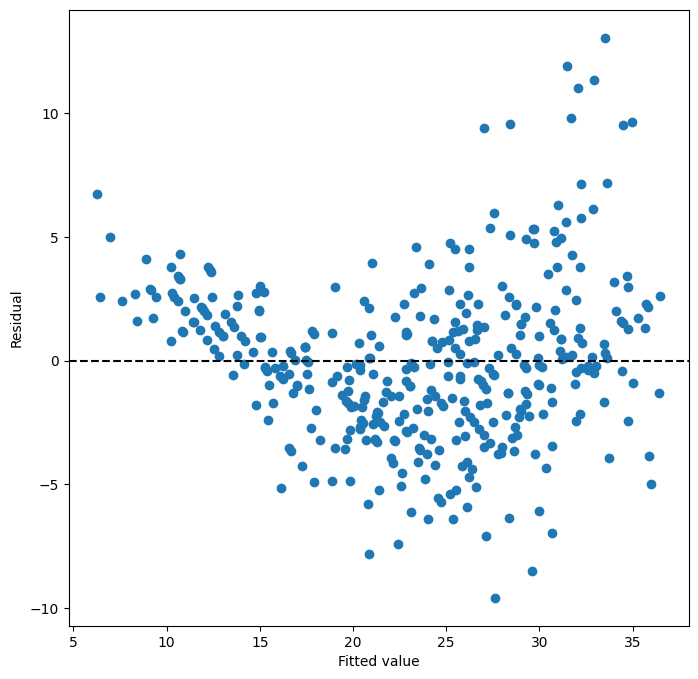

In [26]:
# Ok would be cool to describe all the diagnostic plots tee hee.
# Diagnostic plot 1: Residuals plot:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues , results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

In [27]:
import seaborn as sns
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, 
              line_kws={'color':'red'}, ax=ax)

<Axes: >

In [28]:
#!python -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\marco.valenzuela\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [51]:
#!python -m pip install

ERROR: You must give at least one requirement to install (see "pip help install")

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\marco.valenzuela\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [29]:
import seaborn as sns

print('done')

done


NameError: name 'results' is not defined

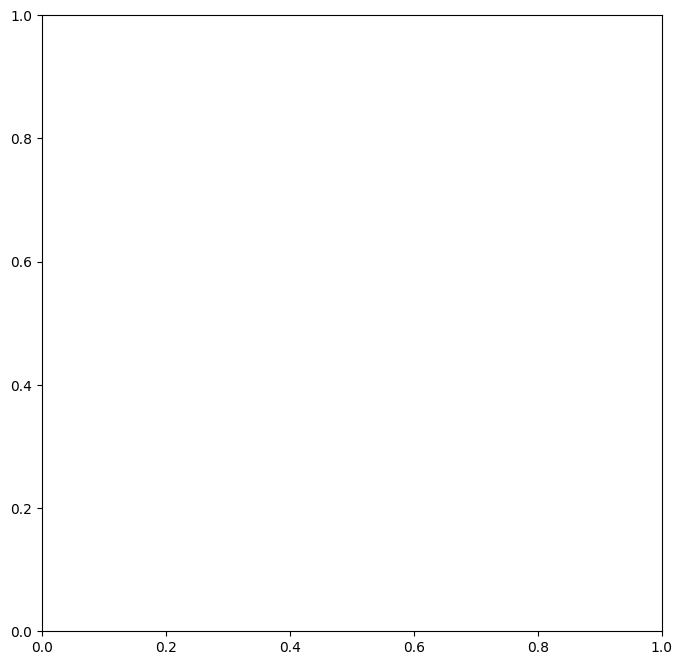

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# We use the results from your sm.OLS fit
ax = plt.subplots(figsize=(8,8))[1]

# This creates the plot with that smoothed red line (lowess)
sns.residplot(x=results.fittedvalues, y=results.resid, 
              lowess=True, 
              line_kws={'color':'red'}, 
              scatter_kws={'alpha': 0.5},
              ax=ax)

ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.set_title('Residual Plot showing Non-linearity')

np.int64(13)

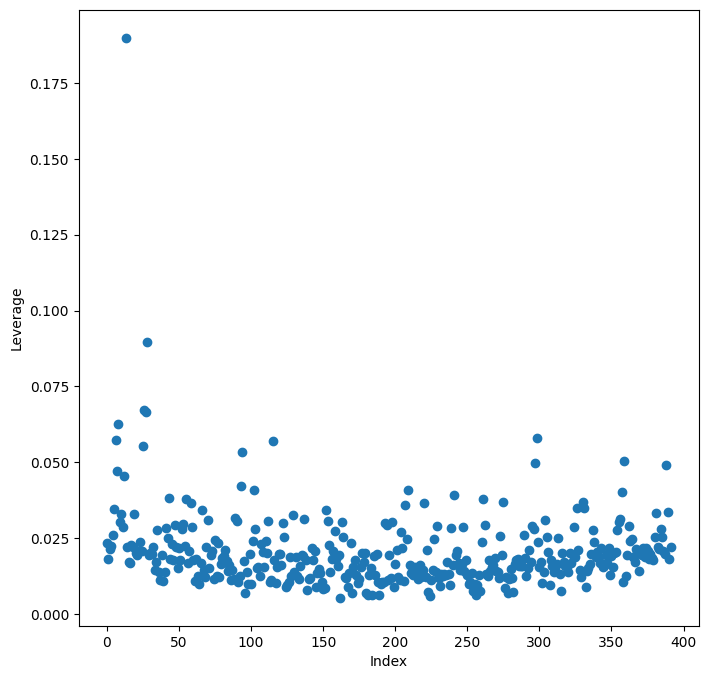

In [31]:
# Now we make a leverage graph
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [34]:
X.iloc[13]

intercept          1.0
cylinders          8.0
displacement     455.0
horsepower       225.0
weight          3086.0
acceleration      10.0
year              70.0
origin             1.0
Name: buick estate wagon (sw), dtype: float64

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?

In [35]:
# Reference code:
X_9e = MS([poly('cylinders', degree=2), poly('displacement', degree=2), 
       poly('horsepower', degree=2), poly('weight', degree=2),
      poly('acceleration', degree=2),
       poly('acceleration', degree=2),
       poly('year', degree=2)]
      ).fit_transform(Auto)
model_9e = sm.OLS(y, X_9e)
results_9e = model_9e.fit()
summarize(results_9e)

# oh dammit, we wanted interactions, not polynomials. Heck


,coef,std err,t,P>|t|
intercept,23.4459,0.140,167.388,0.000
"poly(cylinders, degree=2)[0]",21.5461,10.452,2.062,0.040
"poly(cylinders, degree=2)[1]",-2.8681,3.864,-0.742,0.458
"poly(displacement, degree=2)[0]",-38.1806,14.432,-2.646,0.008
"poly(displacement, degree=2)[1]",13.9532,6.645,2.100,0.036
"poly(horsepower, degree=2)[0]",-50.6764,10.249,-4.945,0.000
"poly(horsepower, degree=2)[1]",10.9829,5.049,2.175,0.030
"poly(weight, degree=2)[0]",-53.8867,11.619,-4.638,0.000
"poly(weight, degree=2)[1]",19.7466,4.941,3.997,0.000
"poly(acceleration, degree=2)[0]",-6.6867,2.688,-2.487,0.013


In [36]:
# Here is our reference code for interactions:

#allvars = list(Carseats.columns.drop('Sales'))
#y = Carseats['Sales']
#final = allvars + [('Income', 'Advertising'),
#('Price', 'Age')]
#X = MS(final).fit_transform(Carseats)
#model = sm.OLS(y, X)
#summarize(model.fit())

# Ok so we need to make a new 'allvars' type variable.
# So the question is, which should we include? Lets first include some and then rethink about this later
#allvars_9e = list(Auto.columns.drop('mpg', 'origin'))
allvars_9e = list(Auto.columns.drop(['origin', 'mpg']))

final_9e = allvars_9e + [('year', 'weight'), ('cylinders', 'displacement')]
#final_9e = allvars_9e# + [('year', 'weight')]

X_9e2 = MS(final_9e).fit_transform(Auto)

model_9e2 = sm.OLS(y, X_9e2)
summarize(model_9e2.fit())

#allvars_9e


,coef,std err,t,P>|t|
intercept,-85.7147,13.70300,-6.255,0.000
cylinders,-2.0973,0.40400,-5.197,0.000
displacement,-0.0779,0.01200,-6.286,0.000
horsepower,-0.0473,0.01300,-3.723,0.000
weight,0.0246,0.00500,5.395,0.000
acceleration,0.1161,0.08800,1.317,0.188
year,1.8460,0.17000,10.835,0.000
year:weight,-0.0004,0.00006,-6.602,0.000
cylinders:displacement,0.0122,0.00200,7.557,0.000


<span style="color:blue"> The interaction between "Year" and "Weight" seems to be statistically significant. The interaction between "Cylinders" and "Displacement" also seems to be statistically significant.</span>

(f) Try a few different transformations of the variables, such as
log(X), $\sqrt{X}$, X2. Comment on your findings.

In [37]:

# We kinda already accidentally did this in part (e) first, lmao. But letsa go again, practice makes time used I suppose.

# So we precalculate the log displacement and add them as new columns in Auto
Auto['log_displacement'] = np.log(Auto['displacement'])
Auto['sqrt_horsepower'] = np.sqrt(Auto['horsepower'])

X_9f = MS([
            'cylinders', 
            
    poly('displacement', degree=2), 
            'log_displacement', 
            'sqrt_horsepower',
            poly('acceleration', degree=2),
            poly('year', degree=2)]
      ).fit_transform(Auto)
model_9f = sm.OLS(y, X_9f)
results_9f = model_9f.fit()
summarize(results_9f)


,coef,std err,t,P>|t|
intercept,47.0921,28.872,1.631,0.104
cylinders,0.9959,0.363,2.747,0.006
"poly(displacement, degree=2)[0]",-65.4345,62.449,-1.048,0.295
"poly(displacement, degree=2)[1]",36.2982,12.740,2.849,0.005
log_displacement,-0.8643,5.513,-0.157,0.876
sqrt_horsepower,-2.4507,0.237,-10.343,0.000
"poly(acceleration, degree=2)[0]",-23.3534,4.471,-5.223,0.000
"poly(acceleration, degree=2)[1]",8.8638,3.520,2.518,0.012
"poly(year, degree=2)[0]",51.8342,3.251,15.942,0.000
"poly(year, degree=2)[1]",20.0900,3.026,6.639,0.000


In [38]:
np.log(4)

np.float64(1.3862943611198906)

## 10. This question should be answered using the Carseats data set.
(a) Fit a multiple regression model to predict Sales using Price,
Urban, and US.

In [39]:
# First we need to load in the Carseats data

Carseats = load_data("Carseats")
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [40]:
# Then we specify the columns we care about:
X_10a = pd.DataFrame({
                            'Intercept': np.ones(Carseats.shape[0]),
                            'Price' : Carseats['Price'],
                            'Urban' : Carseats['Urban'],
                            'US' : Carseats['US']
                     })
#X = MS(final).fit_transform(Carseats)

X_10a[:4]

# This approach doesnt quite work... why not? Well we need to turn the Urban and US columns into 1s and 0s basically.

,Intercept,Price,Urban,US
0,1.0,120,Yes,Yes
1,1.0,83,Yes,Yes
2,1.0,80,Yes,Yes
3,1.0,97,Yes,Yes


In [41]:
# So this way, we can use the MS(XXX).fit_transform(pd.Dataset) to get the right format of the qualitative columns.
# Cool
listvars_10a = ['Price', 'Urban', 'US']

X_10a = MS(listvars_10a).fit_transform(Carseats)

In [42]:
# Now we "fit" the model
y_10a = Carseats['Sales']

model_10a = sm.OLS(y_10a, X_10a)
results_10a = model_10a.fit()

summarize(results_10a)

,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000


(b) Provide an interpretation of each coefficient in the model. Be
careful—some of the variables in the model are qualitative!

<span style="color:blue"> The model works as this: Sales = intercept + Price*-0.0545 + (Indicator if Urban = Yes)*-0.0219 + (Indicator if US = Yes) * 1.2006. The intercept is the estimate for Sales when the price is 0, Urban is 'No' and US is 'No'</span>

(c) Write out the model in equation form, being careful to handle
the qualitative variables properly.

$\hspace{100pt} Sales = 13.0435 - (Price * 0.545) - (Urban_Ind * 0.0219) + (US_Ind * 1.2006)$

(d) For which of the predictors can you reject the null hypothesis
$H_0 : \beta_j = 0$?

<span style="color:blue"> For the Urban[Yes] coefficient, as the P value is way above 0.05. </span>

(e) On the basis of your response to the previous question, fit a
smaller model that only uses the predictors for which there is
evidence of association with the outcome.

In [43]:
listvars_10e = ['Price', 'US']

X_10e = MS(listvars_10e).fit_transform(Carseats)
y_10e = Carseats['Sales']

model_10e = sm.OLS(y_10e, X_10e)
results_10e = model_10e.fit()

summarize(results_10e)

,coef,std err,t,P>|t|
intercept,13.0308,0.631,20.652,0.0
Price,-0.0545,0.005,-10.416,0.0
US[Yes],1.1996,0.258,4.641,0.0


(f) How well do the models in (a) and (e) fit the data?

<span style="color:blue"> For a measure of how well the model fits the data, we want the value of $R^2$, or $Adjusted$ $R^2$</span>


In [44]:
print(f"Model A R-Squared: {results_10a.rsquared:.4f}")
print(f"Model E R-Squared: {results_10e.rsquared:.4f}")

print(f"Model A R-Squared: {results_10a.rsquared_adj:.4f}")
print(f"Model E R-Squared: {results_10e.rsquared_adj:.4f}")

Model A R-Squared: 0.2393
Model E R-Squared: 0.2393
Model A R-Squared: 0.2335
Model E R-Squared: 0.2354


In [45]:
results_10a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           2.39e-23
Time:                        18:22:39   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban[Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [46]:
results_10e.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           2.66e-24
Time:                        18:22:40   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(g) Using the model from (e), obtain 95 % confidence intervals for
the coefficient(s).

In [47]:
# Lab reference: new_predictions.conf_int(alpha=0.05)

results_10a.conf_int(alpha= 0.05)

,0,1
intercept,11.763597,14.323341
Price,-0.064764,-0.044154
Urban[Yes],-0.555973,0.512141
US[Yes],0.691304,1.709841


In [48]:
results_10e.conf_int(alpha= 0.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


(h) Is there evidence of outliers or high leverage observations in the
model from (e)?

np.int64(42)

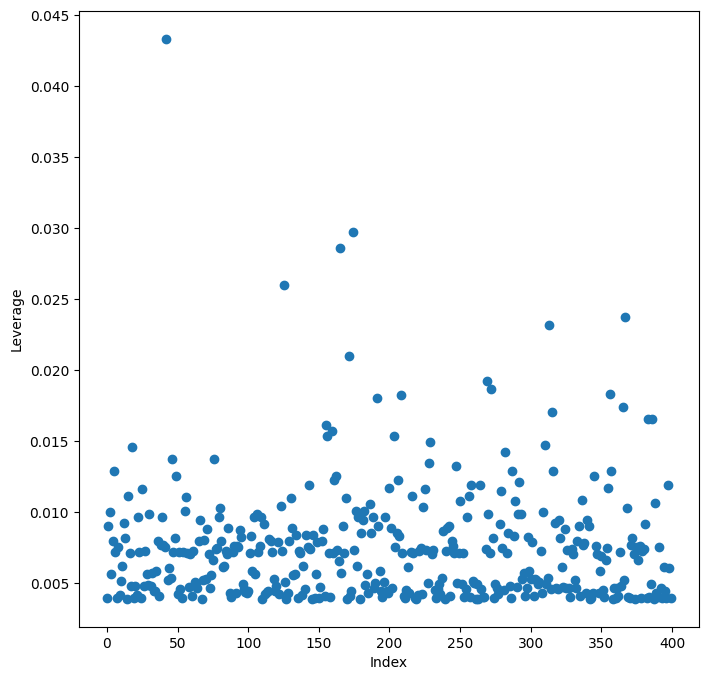

In [50]:
# Now we make a leverage graph
infl_10e = results_10e.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X_10e.shape[0]), infl_10e.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl_10e.hat_matrix_diag)

In [55]:
# Lets actually look at the specific value:
Carseats[['Price', 'US']].iloc[42]

Price    24
US       No
Name: 42, dtype: object

In [57]:
Carseats[['Price']].max()

Price    191
dtype: int64

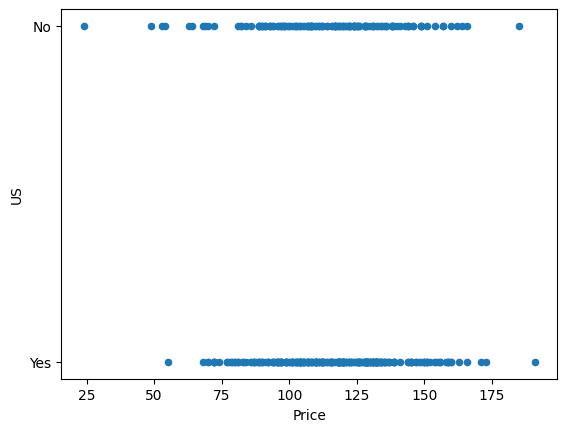

In [58]:
# thats cool, but I want to SEE it
Carseats_10e = Carseats.plot.scatter('Price', 'US')
abline(ax,
    results.params.iloc[0],
    results.params.iloc[1],
    'r--',
    linewidth=3)

In [60]:
Carseats.shape

(400, 11)

In [68]:
# so what is 2p/n?
(X_10e.shape[1]*2)/X_10e.shape[0]

0.015

In [64]:
X_10e.shape

(400, 3)

#### 11. In this problem we will investigate the t-statistic for the null hypothesis
$H_0 : \beta  = 0$ in simple linear regression without an intercept. To
begin, we generate a predictor x and a response y as follows.

In [71]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

y

array([ 0.03988737,  2.50568108,  0.53528207, -1.93716122,  3.02955534,
        1.27567873, -1.94962761, -0.35208242,  2.48252891,  0.4769728 ,
       -0.63172047,  1.23768306, -1.6643195 ,  0.52632237, -0.93031044,
        1.21144201, -0.63513551, -0.1153454 , -2.59768365,  0.15150496,
        1.54022187, -2.07589185,  0.1218984 ,  2.63032739, -2.87442714,
       -4.77895134, -1.60023994, -0.25541189, -0.4134356 , -0.07138162,
        3.88756004, -1.69203944, -1.16051238,  4.36342606,  1.11687273,
        0.48145564, -1.347839  , -4.24655001,  0.34144447, -0.90583805,
       -3.54759848,  0.09050849, -0.19727158, -1.94340527,  0.31499648,
       -0.22989095, -0.15736289, -0.58743458,  1.46991199,  0.62303718,
        1.47503921, -2.2268954 ,  0.40722562, -1.90335511,  1.36777589,
       -0.51627458,  0.6533985 ,  0.11994898, -4.63532214, -0.62936588,
        1.00777098,  0.30891936, -2.59373117, -1.98323503,  1.09932082,
       -0.26984166,  2.44348508,  1.72820652, -3.88998483,  0.38

(a) Perform a simple linear regression of y onto x, without an intercept.
Report the coefficient estimate $\hat{\beta}$, the standard error of
this coefficient estimate, and the t-statistic and p-value associated
with the null hypothesis $H_0 : \beta = 0$. Comment on these
results. (You can perform regression without an intercept using
the keywords argument intercept=False to ModelSpec().)

In [82]:
model_11a = sm.OLS(y, x, intercept=False)
results_11a = model_11a.fit()

summarize(results_11a)

C:\Users\marco.valenzuela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['intercept']
  warnings.warn(msg, ValueWarning)


,coef,std err,t,P>|t|
x1,1.9762,0.117,16.898,0.0


In [87]:
x_with_const = sm.add_constant(x)

model_11a_const = sm.OLS(y, x_with_const)
results_11a = model_11a_const.fit()

summarize(results_11a)

,coef,std err,t,P>|t|
const,-0.0760,0.101,-0.756,0.451
x1,1.9686,0.118,16.734,0.000


<span style="color:blue"> Coefficient Estimate $\hat{\beta}$ = 1.9762. </span>
<span style="color:blue"> Std Error: 0.117 </span>
<span style="color:blue"> $t$-statistic: 16.898</span>
<span style="color:blue"> $p$-value < 0.01 </span>



(b) Now perform a simple linear regression of x onto y without an
intercept, and report the coefficient estimate, its standard error,
and the corresponding t-statistic and p-values associated with
the null hypothesis H0 : # = 0. Comment on these results.

In [89]:
model_11b = sm.OLS(x, y)
results_11b = model_11b.fit()

summarize(results_11b)

,coef,std err,t,P>|t|
x1,0.3757,0.022,16.898,0.0


In [98]:
rng = np.random.default_rng(2)
x = rng.normal(size=1000)
y = 2 * x + rng.normal(size=1000)

model_11b = sm.OLS(x, y)
results_11b = model_11b.fit()

summarize(results_11b)

,coef,std err,t,P>|t|
x1,0.4,0.000063,6326.529,0.0


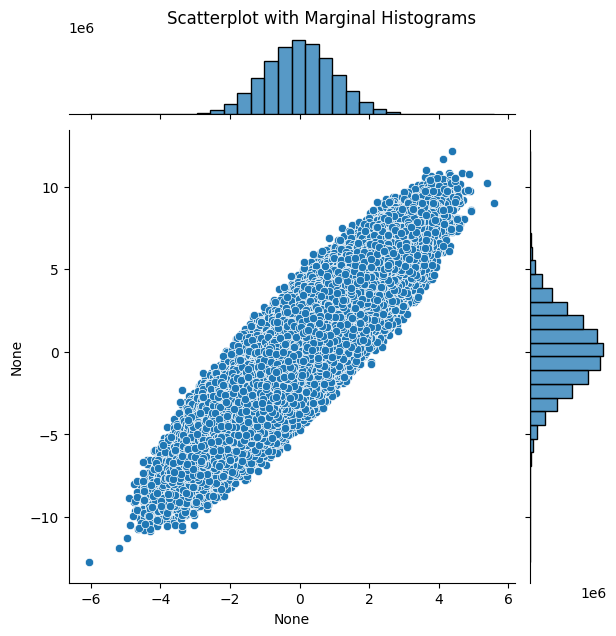

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the data you generated
# x = rng.normal(size=1000)
# y = 2 * x + rng.normal(size=1000)

# Create the joint plot
g = sns.jointplot(x=x, y=y, kind='scatter', marginal_kws=dict(bins=30, fill=True))

# Add a title (requires a little tweak to move it up so it doesn't overlap)
g.fig.suptitle("Scatterplot with Marginal Histograms", y=1.02)

plt.show()

KeyboardInterrupt: 

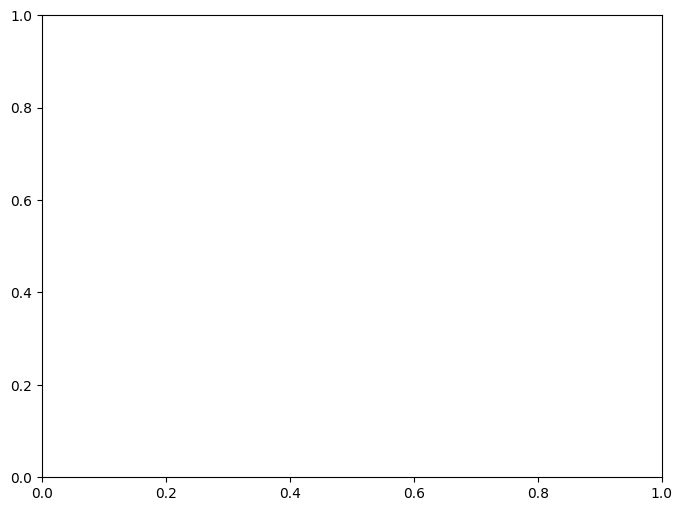

In [103]:
plt.figure(figsize=(8, 6))
sns.histplot(y, bins=30, kde=True, color='royalblue')

plt.title('Seaborn Histogram with Density Curve')
plt.show()

In [1]:
rng = np.random.default_rng(2)
x = rng.normal(size=100)
epsilon = rng.normal(size=100)
y = 2 * x + epsilon
#y = 2 * x + rng.normal(size=100)

model_11b = sm.OLS(x, y)
results_11b = model_11b.fit()

summarize(results_11b)

NameError: name 'np' is not defined

In [107]:
ones_list = [2] * 100

In [108]:
rng = np.random.default_rng(2)
x = rng.normal(size=100)
y = ones_list + rng.normal(size=100)

model_11b_2 = sm.OLS(ones_list, y)
results_11b_2 = model_11b.fit()

summarize(results_11b)

,coef,std err,t,P>|t|
x1,0.4,0.000063,6326.529,0.0


In [106]:
2*ones_list

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [4]:
import numpy as np
import seaborn as sm

In [51]:
rng = np.random.default_rng(1)
x = rng.normal(size=1000)
epsilon = rng.normal(size=1000)
y = 2 * x + epsilon
#y = 2 * x + rng.normal(size=100)

model_11b = sm.OLS(x, y)
results_11b = model_11b.fit()

summarize(results_11b)

,coef,std err,t,P>|t|
x1,0.3892,0.006,62.247,0.0


(e) Using the results from (d), argue that the t-statistic for the regression
of y onto x is the same as the t-statistic for the regression
of x onto y.

<span style="color:blue"> The equation is symetric, so the *t*-statistic should be so as well </span>

(f) In R, show that when regression is performed with an intercept,
the t-statistic for H0 : #1 = 0 is the same for the regression of y
onto x as it is for the regression of x onto y.

In [25]:
x_with_const = sm.add_constant(x)

x_with_const

array([[ 1.        ,  0.18905338],
       [ 1.        , -0.52274844],
       [ 1.        , -0.41306354],
       ...,
       [ 1.        ,  1.19999694],
       [ 1.        , -1.66901266],
       [ 1.        , -0.47024369]], shape=(1000, 2))

In [42]:
epsilon = rng.normal(size=1000)
y_with_const = 2 * x_with_const[:,1] + epsilon
#y = 2 * x + rng.normal(size=100)

model_11e = sm.OLS(x_with_const, y_with_const)
results_11e = model_11b.fit()

summarize(results_11b)

,coef,std err,t,P>|t|
x1,0.4019,0.006,65.647,0.0


In [53]:
model_11e_2 = sm.OLS(y_with_const, x_with_const)
results_11e_2 = model_11b.fit()

summarize(results_11e_2)

,coef,std err,t,P>|t|
x1,0.3892,0.006,62.247,0.0


In [54]:
type(x_with_const)

numpy.ndarray

In [55]:
x_with_const[:,1]

array([ 1.89053382e-01, -5.22748441e-01, -4.13063543e-01, -2.44146738e+00,
        1.79970738e+00,  1.14416587e+00, -3.25422837e-01,  7.73806587e-01,
        2.81210670e-01, -5.53822836e-01,  9.77567451e-01, -3.10556547e-01,
       -3.28823904e-01, -7.92146755e-01,  4.54958071e-01, -9.91980517e-02,
        5.45288714e-01, -6.07185700e-01,  1.26827847e-01, -8.92274043e-01,
        8.41464972e-01,  1.88035087e-01,  3.30571008e-01,  4.10503913e-01,
       -1.01075750e+00,  7.83180996e-01,  2.05670282e+00, -1.63844250e+00,
       -1.72941147e+00, -1.50483141e+00,  8.41458893e-01,  1.28715657e-01,
        1.07834244e+00,  7.22430872e-01,  2.10571812e-01,  2.84038145e-01,
       -1.69760498e-01,  8.68460211e-01, -1.12971596e+00, -4.21858826e-01,
        2.42938853e-01,  1.80142086e+00, -7.64464116e-01, -1.07906046e+00,
       -5.63287199e-01,  9.69272201e-01, -2.35005507e-01,  1.32434702e+00,
       -1.87252952e+00,  1.12852314e+00,  1.03486624e+00, -1.41866569e+00,
        1.53581887e-01,  

In [56]:
x_with_const = sm.add_constant(x)

model_11e_const = sm.OLS(y, x_with_const)
results_11e = model_11e_const.fit()

summarize(results_11e)

,coef,std err,t,P>|t|
const,0.0299,0.032,0.920,0.358
x1,2.0442,0.033,62.199,0.000


In [57]:
y_with_const = sm.add_constant(y)

model_11e_const_inv = sm.OLS(x, y_with_const)
results_11e_inv = model_11e_const_inv.fit()

summarize(results_11e_inv)

,coef,std err,t,P>|t|
const,-0.0227,0.014,-1.607,0.108
x1,0.3889,0.006,62.199,0.000


## 12. This problem involves simple linear regression without an intercept.

(a) Recall that the coefficient estimate $\hat{\beta}$ for the linear regression of $Y$ onto $X$ without an intercept is given by (3.38). Under what
circumstance is the coefficient estimate for the regression of X
onto Y the same as the coefficient estimate for the regression of
Y onto X?

<span style="color:blue"> A sufficient condition is that the sum of $x_i^2$ is the same as the sume of $y_i^2$ </span>

(b) Generate an example in $Python$ with $n =$ 100 observations in which the coefficient estimate for the regression of X onto Y is *different* from the coefficient estimate for the regression of $Y$ onto $X$.

In [76]:
# This should be easy, the previous question already had this (kinda the point of the exercise was the non symmetry part). 
# Y should have a different variance

X = rng.normal(size=100, scale=5)
epsilon = rng.normal(size=100, scale=10)
ones_list = [2] * 100

Y = X + ones_list + epsilon

model_12b_1 = sm.OLS(X, Y)
results_12b_1 = model_12b_1.fit()

model_12b_2 = sm.OLS(Y, X)
results_12b_2 = model_12b_2.fit()

summarize(results_12b_2)


,coef,std err,t,P>|t|
x1,1.3666,0.192,7.116,0.0


In [77]:
summarize(results_12b_1)

,coef,std err,t,P>|t|
x1,0.2476,0.035,7.116,0.0


(c) Generate an example in Python with n = 100 observations in which the coefficient estimate for the regression of $X$ onto $Y$ is *the same* as the coefficient estimate for the regression of $Y$ onto $X$.

In [70]:
# Ok we want to generate X and Y s.t. var(X) = var(Y), and mean(X) = mean(Y) = 0.
# So idea: Z = N(0,5). E_1 = N(0,1). E_2 = N(0,1). X = Z + E_1. Y = Z + E_2. They are related. Means of 0. Same variance.

rng = np.random.default_rng(1)
Z = rng.normal(size=100, scale = 5)
E_1 = rng.normal(size=100, scale = 1)
# E_2 = rng.normal(size=100, scale = 1)

X = Z + E_1
Y = Z - E_1

model_12c_1 = sm.OLS(X, Y)
results_12c_1 = model_12c_1.fit()

model_12c_2 = sm.OLS(Y, X)
results_12c_2 = model_12c_2.fit()

summarize(results_12c_2)

,coef,std err,t,P>|t|
x1,0.9533,0.031,30.786,0.0


In [78]:
summarize(results_12c_1)

,coef,std err,t,P>|t|
x1,0.9498,0.031,30.786,0.0


In [79]:
# Alright I didnt get it right. They want the COEFFICIENT to be the same. So even if the distribution is the same, the random
# variations are gonna make a difference. They need sum of x^2 to be equal to sum of y^2. 

X = rng.normal(size=100)
Y = X[::-1]

## 13.
In this exercise you will create some simulated data and will fit simple
linear regression models to it. Make sure to use the default random
number generator with seed set to 1 prior to starting part (a) to
ensure consistent results.

#### (a) 
Using the normal() method of your random number generator,
create a vector, x, containing 100 observations drawn from a
N(0, 1) distribution. This represents a feature, X.

In [15]:
rng = np.random.default_rng(1)

x = rng.normal(size=100)

#### (b)
Using the normal() method, create a vector, eps, containing 100
observations drawn from a N(0, 0.25) distribution—a normal
distribution with mean zero and variance 0.25.

In [39]:
eps = rng.normal(0, 0.25, size=100)

(c) Using x and eps, generate a vector y according to the model

$\hspace{100pt} Y = -1 + 0.5X + \epsilon \hspace{100pt} (3.39)$

What is the length of the vector y? What are the values of $\beta_0$
and $\beta_1$ in this linear model?

<span style="color:blue"> y has length 100. The true values are $\beta_0 = -1$ and $\beta_1 = 0.5$ </span>

In [40]:
y = -1 + 0.5 * x + eps
y

array([-0.37010034, -0.08417259, -1.10097422, -1.55837484, -0.71564767,
       -0.7827052 , -1.58488586, -0.24265457, -1.06000868, -0.92695471,
       -0.86041815, -0.88853368, -1.42805515, -1.22236494, -1.27442485,
       -0.99321255, -1.08963597, -1.19795161, -1.47438573, -1.11442363,
       -1.06920446, -0.9494986 , -0.43376707, -0.53080024, -2.52177657,
       -2.07613533, -1.40350924, -1.08139898, -1.17880801, -1.07780313,
        0.14873054, -1.45536704, -1.28883119, -0.48343065, -0.57152018,
       -0.60357745, -1.61009849, -1.63145706, -1.09154258, -1.22703999,
       -1.58974335, -1.38623094, -0.98536584, -1.87381283, -0.59607745,
       -1.10292314, -1.36712171, -1.09843528, -0.791827  , -0.4732019 ,
       -0.92447796, -1.4240502 , -0.57273065, -1.43738323, -0.39073479,
       -1.65336873, -0.76018818, -0.99077362, -1.51311413, -1.21421957,
       -1.18857881, -0.70865794, -1.93117626, -1.81140256, -0.89032701,
       -1.57363966, -0.87524863, -0.63395602, -1.59970874, -1.10

(d) Create a scatterplot displaying the relationship between x and
y. Comment on what you observe.

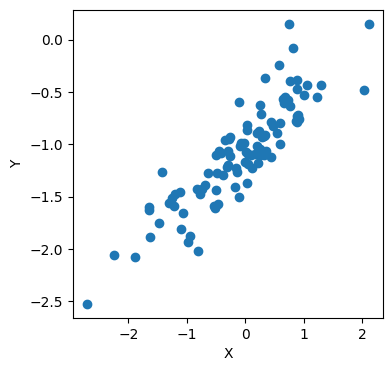

In [41]:
from matplotlib.pyplot import subplots

ax = subplots(figsize=(4,4))[1]
ax.scatter(x, y)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

(e) Fit a least squares linear model to predict y using x. Comment
on the model obtained. How do $\hat{\beta_0}$ and $\hat{\beta_1}$ compare to $\beta_0$ and
$\beta_1$?

In [42]:
rng = np.random.default_rng(1)

x = rng.normal(size=100)
y = -1 + 0.5 * x + eps
x_with_const = sm.add_constant(x)


model_13e = sm.OLS(y, x_with_const)
results_13e = model_13e.fit()
summarize(results_13e)

# The values are -1.08 for the and  

,coef,std err,t,P>|t|
const,-1.0405,0.023,-44.957,0.0
x1,0.4968,0.027,18.348,0.0


#### (f) 
Display the least squares line on the scatterplot obtained in (d).
Draw the population regression line on the plot, in a different
color. Use the legend() method of the axes to create an appropriate
legend.

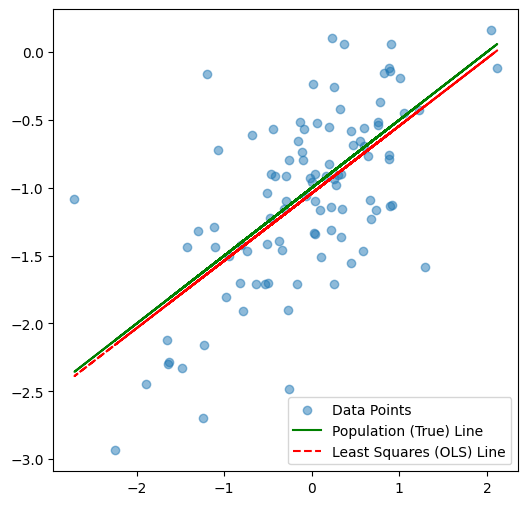

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reset the values of x and y
rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(size=100, scale=0.5)
y = -1 + 0.5 * x + eps

fig, ax = plt.subplots(figsize=(6,6))

# We use the results from your sm.OLS fit
ax.scatter(x, y, alpha=0.5, label='Data Points')
ax.plot(x, -1 + 0.5 * x, color='green', label='Population (True) Line')
intercept, slope = results_13e.params
ax.plot(x, intercept + slope * x, color='red', linestyle='--', label='Least Squares (OLS) Line')

# 4. The Legend
ax.legend()

plt.show()
# Ok this is dumb. They want us to fit a least squares line. LINE. Thats not a straight line is it Mansley?

In [65]:
print(f"True Slope: 0.5")
print(f"Estimated Slope: {results_13e.params[1]}")

True Slope: 0.5
Estimated Slope: 0.4968048886209811


In [21]:
ax = plt.subplots(figsize=(6,6))[1]

# This creates the plot with that smoothed red line (lowess)
sns.residplot(x=x, y=y, 
              lowess=True, 
              line_kws={'color':'red'}, 
              scatter_kws={'alpha': 0.5},
              ax=ax)

ax.set_xlabel('X value')
ax.set_ylabel('Y Value')
ax.set_title('Scatter Plot X vs Y with line of best fit I think')

(100,)

#### (g)
Now fit a polynomial regression model that predicts y using x
and x2. Is there evidence that the quadratic term improves the
model fit? Explain your answer.

In [78]:
df1 = pd.DataFrame(x_with_const)
df1['x2'] = x**2
df1.columns = ['Intercept', 'X', 'X2']
df1

#Now we can use this reference:
model_13g = sm.OLS(y, df1)
results_13g = model_13g.fit()
summarize(results_13g)


,coef,std err,t,P>|t|
Intercept,-1.0364,0.060,-17.399,0.000
X,0.4831,0.063,7.647,0.000
X2,-0.0024,0.045,-0.052,0.959


<span style="color:blue"> The model does have a lower or equal R squared, but seeing the vale of the t statistic, it is a worse model </span>

#### (h) 
Repeat (a)–(f) after modifying the data generation process in
such a way that there is less noise in the data. The model (3.39)
should remain the same. You can do this by decreasing the variance
of the normal distribution used to generate the error term
" in (b). Describe your results.

In [79]:
rng = np.random.default_rng(1)

eps = rng.normal(0, 0.1, size=100)
x = rng.normal(size=100)
y = -1 + 0.5 * x + eps
x_with_const = sm.add_constant(x)


model_13e = sm.OLS(y, x_with_const)
results_13e = model_13e.fit()
summarize(results_13e)

,coef,std err,t,P>|t|
const,-1.0075,0.009,-116.848,0.0
x1,0.4977,0.009,57.418,0.0


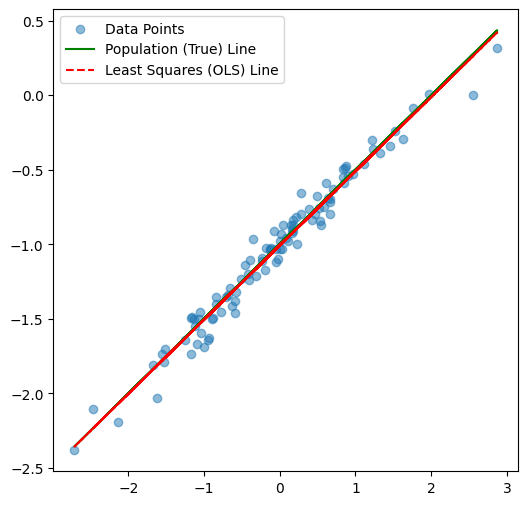

In [80]:
fig, ax = plt.subplots(figsize=(6,6))

# We use the results from your sm.OLS fit
ax.scatter(x, y, alpha=0.5, label='Data Points')
ax.plot(x, -1 + 0.5 * x, color='green', label='Population (True) Line')
intercept, slope = results_13e.params
ax.plot(x, intercept + slope * x, color='red', linestyle='--', label='Least Squares (OLS) Line')

# 4. The Legend
ax.legend()

plt.show()

In [81]:
df2 = pd.DataFrame(x_with_const)
df2['x2'] = x**2
df2.columns = ['Intercept', 'X', 'X2']
df2

#Now we can use this reference:
model_13h = sm.OLS(y, df2)
results_13h = model_13h.fit()
summarize(results_13h)

,coef,std err,t,P>|t|
Intercept,-0.9950,0.010,-99.143,0.000
X,0.4976,0.008,58.670,0.000
X2,-0.0127,0.005,-2.313,0.023


<span style="color:blue">  What I saw: The regression line and the least squares line were significantly closer together. The p values for the first model were lower. However, what I didnt expect was for the p value of X2 to also be lower, below 0.5 in fact. However, the estimate for X2 is -0.0127, which is very low. In a sense, the fact that there was less range of values of X allowed the X2 intercept to not show some of its more egregious behaviors at the outskirts, which would previously been observed in the higher noise part. I thinks. Its like its an X1 range problem.</span>

In [82]:
#(h) skipped due to similarity.

#### (j) 
What are the confidence intervals for #0 and #1 based on the
original data set, the noisier data set, and the less noisy data
set? Comment on your results.

In [83]:
# Well we would need to do (h) to get the confidence intervals for (h) lmao
# But I think we can "settle" on getting one set of C.I.s

results_13h.conf_int(alpha=0.05)

#Thats good nuff 4 me

,0,1
Intercept,-1.014881,-0.975045
X,0.480778,0.514446
X2,-0.023608,-0.001803


### 14. This problem focuses on the collinearity problem.
#### (a) 
Perform the following commands in Python:

rng = np.random.default_rng (10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

The last line corresponds to creating a linear model in which y is
a function of x1 and x2. Write out the form of the linear model.
What are the regression coefficients?

In [13]:
rng = np.random.default_rng(1)

rng = np.random.default_rng (10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

<span style="color:blue"> Answer here: </span>

$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2$

$\beta_0 = 2$, $\beta_1 = 2$, $\beta_3 = 0.3$


#### (b)
What is the correlation between x1 and x2? Create a scatterplot
displaying the relationship between the variables.

In [16]:
np.corrcoef(x1, x2)[0,1]

np.float64(0.772324497691354)

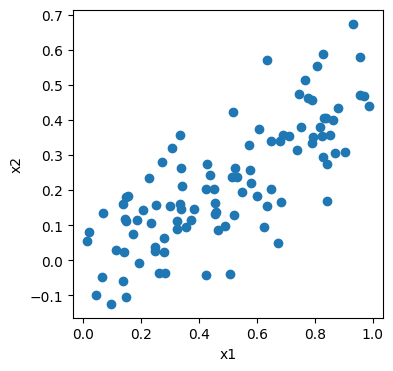

In [17]:
ax = subplots(figsize=(4,4))[1]
ax.scatter(x1, x2)
ax.set_xlabel('x1')
ax.set_ylabel('x2');

plt.show()

#### (c) 
Using this data, fit a least squares regression to predict y using
x1 and x2. Describe the results obtained. What are $\hat{\beta_0}$, $\hat{\beta_1}$, and
$\hat{\beta_2}$? How do these relate to the true $\beta_0$, $\beta_1$, and $\beta_2$? Can you
reject the null hypothesis $H_0 : \beta_1 = 0$? How about the null
hypothesis $H_0 : \beta_2 = 0$?

In [10]:
x1_with_const = sm.add_constant(x1)

df_14 = pd.DataFrame(x1_with_const)
df_14['x2'] = x2
df_14.columns = ['Intercept', 'X1', 'X2']
df_14

model_14c = sm.OLS(y, df_14)
results_14c = model_14c.fit()
summarize(results_14c)

,coef,std err,t,P>|t|
Intercept,1.9579,0.190,10.319,0.000
X1,1.6154,0.527,3.065,0.003
X2,0.9428,0.831,1.134,0.259


<span style="color:blue"> We can not reject the first Null hypothesis, but we could reject the second. it makes me wonder what would have happened had we switched the order, in theory nothing but I am gonna test it. Ok I tested it, and only one is enough. My question is if we had two almost perfectly collinear variables, should their relevance in the OLS not also be with similar values? What decided x1 "won" in this case? </span>


In [18]:
# Ok this was just an investigation of mine to confirm that the t-statistics dont change because of what order you inpu the parameters.
# Kinda duh, but still did it
x2_with_const = sm.add_constant(x2)

df_14_i = pd.DataFrame(x2_with_const)
df_14_i['x1'] = x1
df_14_i.columns = ['Intercept', 'X2', 'X1']

model_14c_i = sm.OLS(y, df_14_i)
results_14c_i = model_14c_i.fit()
summarize(results_14c_i)

,coef,std err,t,P>|t|
Intercept,1.9579,0.190,10.319,0.000
X2,0.9428,0.831,1.134,0.259
X1,1.6154,0.527,3.065,0.003


#### (d) 
Now fit a least squares regression to predict y using only x1.
Comment on your results. Can you reject the null hypothesis
H0 : #1 = 0?

In [20]:
#This part is already done, so all we need to do is to NOT add x_2
#x1_with_const = sm.add_constant(x1)

df_14_d = pd.DataFrame(x1_with_const)
#df_14['x2'] = x2
df_14_d.columns = ['Intercept', 'X1']
df_14_d

model_14d = sm.OLS(y, df_14_d)
results_14d = model_14d.fit()
summarize(results_14d)

,coef,std err,t,P>|t|
Intercept,1.9371,0.189,10.242,0.0
X1,2.0771,0.335,6.196,0.0


In [ ]:
#The predicted values are closer now. We can reject the null hypothesis that H_0 is 0, as the p value is very low.

(e) Now fit a least squares regression to predict $y$ using only $x_2$.
Comment on your results. Can you reject the null hypothesis
$H_0 : \beta_1 = 0$?

In [21]:
df_14_e = pd.DataFrame(x2_with_const)
#df_14['x2'] = x2
df_14_e.columns = ['Intercept', 'X2']
df_14_e

model_14e = sm.OLS(y, df_14_e)
results_14e = model_14e.fit()
summarize(results_14e)

,coef,std err,t,P>|t|
Intercept,2.3239,0.154,15.124,0.0
X2,2.9103,0.550,5.291,0.0


<span style="color:blue"> Since x_1 and x_2 are highly correlated, and x1 in reality has a strong positive association with y, in the absence of x1, it makes sense that x2 would be used to "account" for x_1. You can reject the null hypothesis that $H_0: \beta_1 = 0$. I don't think these results contradict each other, its just from the nature of x_1 being a good predictor of y, and x_2 being associated with higher x_1. </span>

#### g) 
Suppose we obtain one additional observation, which was unfortunately
mismeasured. We use the function np.concatenate() to add this additional observation to each of *x_1*, *x_2*, and *y*.


In [22]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

Re-fit the linear models from (c) to (e) using this new data. What
effect does this new observation have on the each of the models?
In each model, is this observation an outlier? A high-leverage
point? Both? Explain your answers

In [24]:
# C's model:
x1_with_const = sm.add_constant(x1)

df_14g_i = pd.DataFrame(x1_with_const)
df_14g_i['x2'] = x2
df_14g_i.columns = ['Intercept', 'X1', 'X2']
df_14g_i

model_14g_i = sm.OLS(y, df_14g_i)
results_14g_i = model_14g_i.fit()
summarize(results_14g_i)

,coef,std err,t,P>|t|
Intercept,2.0618,0.192,10.720,0.000
X1,0.8575,0.466,1.838,0.069
X2,2.2663,0.705,3.216,0.002


np.int64(100)

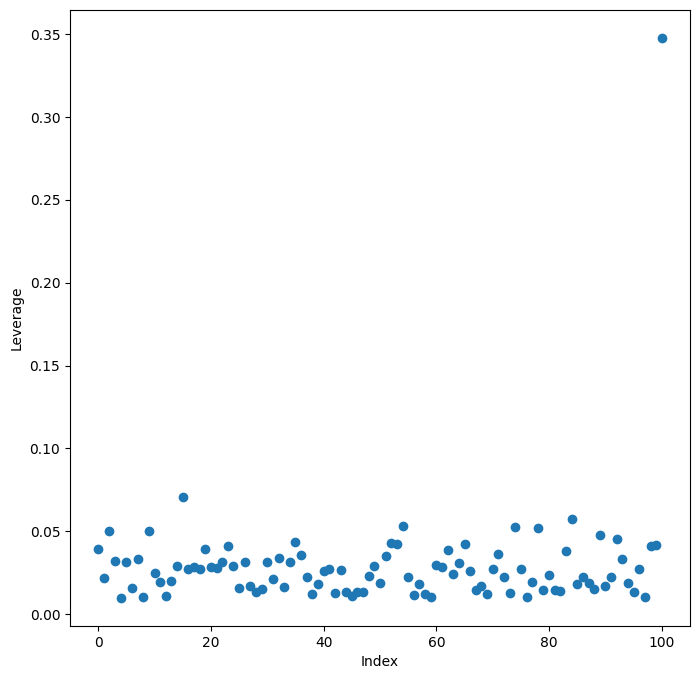

In [26]:
# Lets check the leverage of the points
infl_14g_i = results_14g_i.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(df_14g_i.shape[0]), infl_14g_i.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl_14g_i.hat_matrix_diag)

In [27]:
# Ok now lets check the actual results. We define the function to plot a line from a to b.
def abline(ax, b, m, *args , **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim , ylim , *args , **kwargs)

ax = df_14g_i.plot.scatter('lstat', 'medv')
abline(ax,
    results.params.iloc[0],
    results.params.iloc[1],
    'r--',
    linewidth=3)

In [29]:
df_14g_i_withy = df_14g_i
df_14g_i_withy['Y'] = y
df_14g_i_withy

,Intercept,X1,X2,Y
0,1.0,0.956002,0.469359,4.356977
1,1.0,0.207682,0.142509,3.677789
2,1.0,0.828445,0.587699,3.482079
3,1.0,0.149282,0.181141,2.369093
4,1.0,0.512805,0.236458,1.413295
...,...,...,...,...
96,1.0,0.790513,0.456659,3.460998
97,1.0,0.531602,0.236308,3.355095
98,1.0,0.013037,0.054343,2.336922
99,1.0,0.019875,0.079619,4.566538


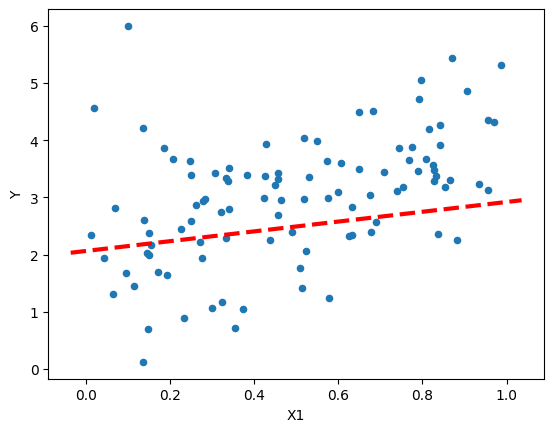

In [30]:
# This seems like a really dumb way to do this lmao. But I guess...
ax = df_14g_i_withy.plot.scatter('X1', 'Y')
abline(ax,
    results_14g_i.params.iloc[0],
    results_14g_i.params.iloc[1],
    'r--',
    linewidth=3)
# Also this isn't what they are asking for. We need a residual plot

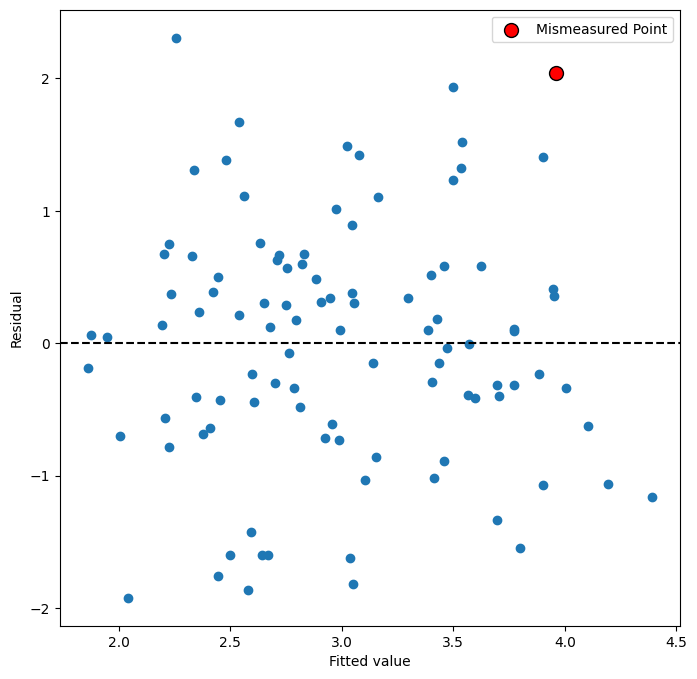

In [39]:
# Residual Plot:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results_14g_i.fittedvalues , results_14g_i.resid)

# 1. Identify the last fitted value and residual
new_point_fitted = results_14g_i.fittedvalues.iloc[-1]
new_point_resid = results_14g_i.resid.iloc[-1]

# 2. Overlay it on the existing 'ax' in red
ax.scatter(new_point_fitted, new_point_resid, 
           color='red', s=100, edgecolor='black', label='Mismeasured Point')

ax.legend()

ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

## 15. 
This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.

#### (a)
For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.

In [7]:
Boston = load_data("Boston")


Boston.columns

Boston.head()

# 13 is the number it SHOULD be I thinks
for col_name, data_type in Boston.dtypes.items():
    print(f"Column '{col_name}' is of datatype '{data_type}' ")

#type(Boston.columns[2])

#Boston.shape
#Boston[[0]][0]

Column 'crim' is of datatype 'float64' 
Column 'zn' is of datatype 'float64' 
Column 'indus' is of datatype 'float64' 
Column 'chas' is of datatype 'int64' 
Column 'nox' is of datatype 'float64' 
Column 'rm' is of datatype 'float64' 
Column 'age' is of datatype 'float64' 
Column 'dis' is of datatype 'float64' 
Column 'rad' is of datatype 'int64' 
Column 'tax' is of datatype 'int64' 
Column 'ptratio' is of datatype 'float64' 
Column 'lstat' is of datatype 'float64' 
Column 'medv' is of datatype 'float64' 


In [8]:
# Iterating through the Series of dtypes
for col_name, data_type in Boston.dtypes.items():
    if data_type == 'object':
        print(f"Column '{col_name}' contains strings (objects).")
    else:
        print('nothing')


nothing
nothing
nothing
nothing
nothing
nothing
nothing
nothing
nothing
nothing
nothing
nothing
nothing


In [9]:
X_terms = Boston.columns.drop('medv')
X_data = Boston[X_terms]

y = Boston[['medv']]
model = sm.OLS(y, X_data)
results = model.fit()

summarize(results)

,coef,std err,t,P>|t|
crim,-0.1126,0.035,-3.194,0.001
zn,0.0502,0.015,3.388,0.001
indus,-0.0226,0.066,-0.340,0.734
chas,3.1635,0.929,3.406,0.001
nox,-0.9158,3.439,-0.266,0.790
rm,6.1869,0.315,19.669,0.000
age,-0.0041,0.014,-0.291,0.771
dis,-0.8696,0.201,-4.336,0.000
rad,0.1086,0.068,1.604,0.109
tax,-0.0093,0.004,-2.297,0.022


In [10]:
# ok they want this for EACH fucking result. So lets set up how to do it for one, then we can try and iterate it.
X_data_iterated = Boston


X_temp = Boston[[X_data.columns[1]]]
y = Boston[['medv']]
model_temp = sm.OLS(y, X_temp)
results_temp = model_temp.fit()

print(summarize(results_temp)) 

      coef  std err      t  P>|t|
zn  0.4959    0.035  13.98    0.0


In [11]:
j = 0

for i in X_data:
    #X_temp = Boston[[X_data.columns[1]]]
    X_temp = Boston[[i]]
    y = Boston[['medv']]
    model_temp = sm.OLS(y, X_temp)
    results_temp = model_temp.fit()
    print(summarize(results_temp))
    print('-------------------------------------')

        coef  std err     t  P>|t|
crim  0.5842    0.113  5.16    0.0
-------------------------------------
      coef  std err      t  P>|t|
zn  0.4959    0.035  13.98    0.0
-------------------------------------
         coef  std err       t  P>|t|
indus  1.2894     0.06  21.595    0.0
-------------------------------------
       coef  std err      t  P>|t|
chas  28.44    3.918  7.259    0.0
-------------------------------------
       coef  std err       t  P>|t|
nox  37.511     0.93  40.319    0.0
-------------------------------------
      coef  std err      t  P>|t|
rm  3.6534    0.054  67.93    0.0
-------------------------------------
       coef  std err      t  P>|t|
age  0.2636    0.009  30.25    0.0
-------------------------------------
       coef  std err       t  P>|t|
dis  4.7985    0.129  37.149    0.0
-------------------------------------
       coef  std err       t  P>|t|
rad  1.1068    0.068  16.316    0.0
-------------------------------------
       coef  std err

In [12]:
for i in range(X_data.shape[1]):
    print(i)


0
1
2
3
4
5
6
7
8
9
10
11


      coef  std err      t  P>|t|
zn  0.0014    0.016  0.086  0.931
-------------------------------------

         coef  std err       t  P>|t|
indus  0.3754    0.027  13.919    0.0
-------------------------------------

        coef  std err      t  P>|t|
chas  1.8517    1.575  1.176   0.24
-------------------------------------

       coef  std err       t  P>|t|
nox  7.5467     0.65  11.602    0.0
-------------------------------------

      coef  std err      t  P>|t|
rm  0.5348    0.061  8.749    0.0
-------------------------------------

       coef  std err       t  P>|t|
age  0.0606    0.005  12.363    0.0
-------------------------------------

       coef  std err      t  P>|t|
dis  0.3638    0.094  3.862    0.0
-------------------------------------

      coef  std err       t  P>|t|
rad  0.487    0.024  20.551    0.0
-------------------------------------

       coef  std err       t  P>|t|
tax  0.0119    0.001  15.316    0.0
-------------------------------------

         

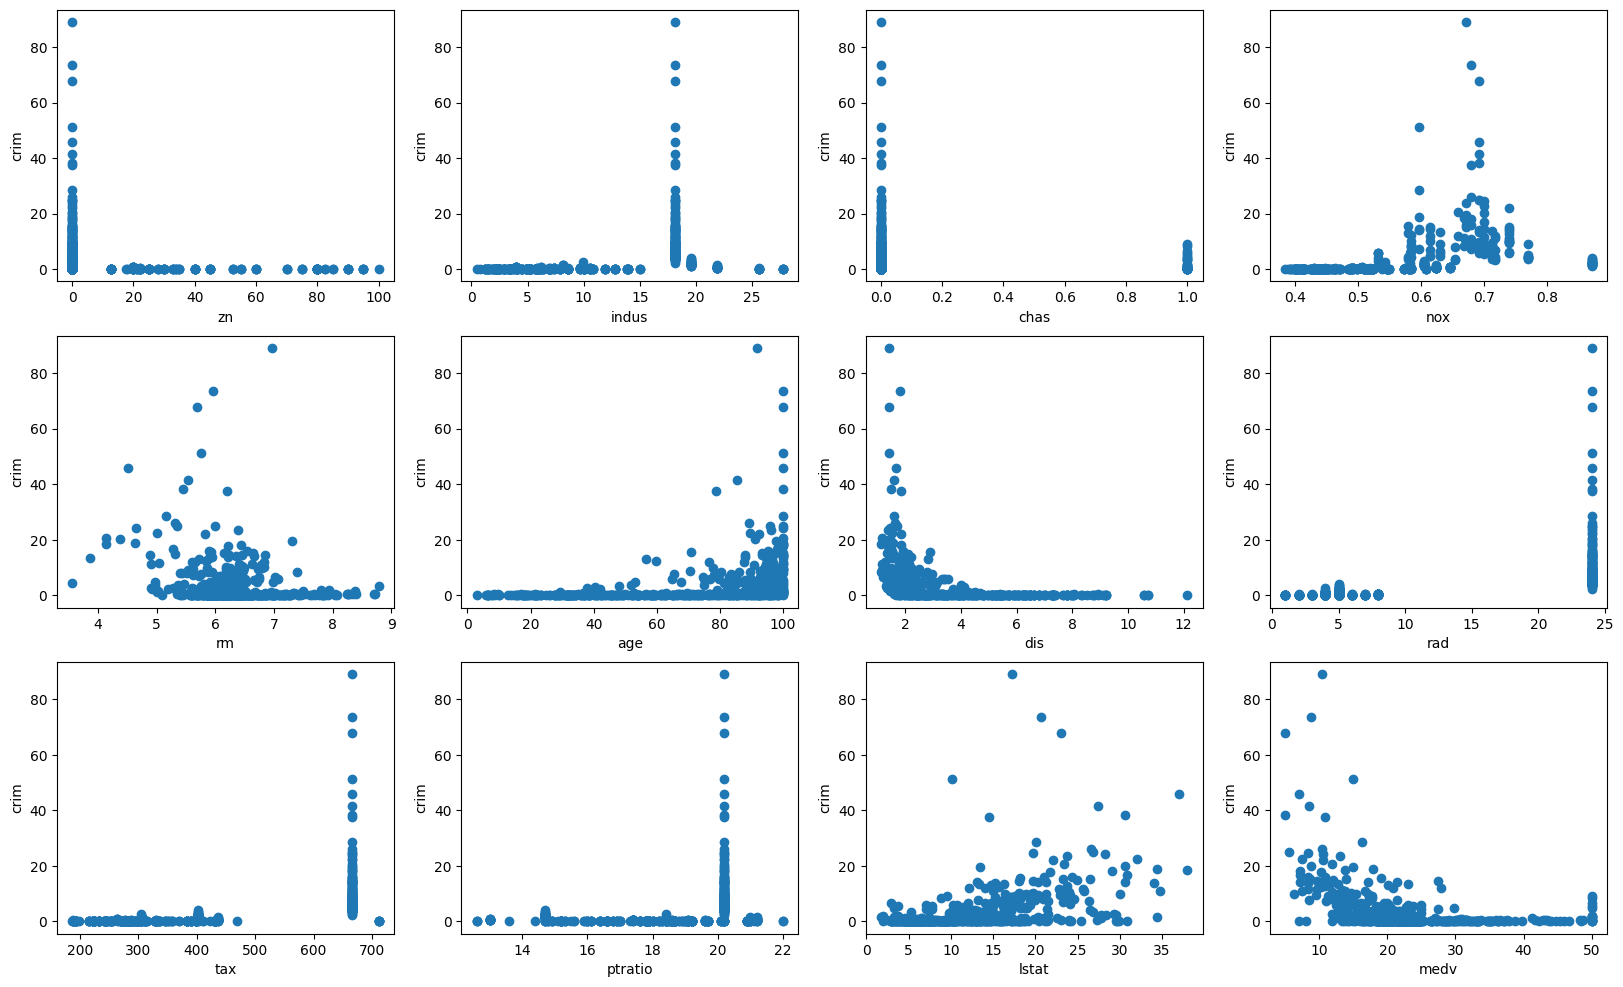

In [13]:
X_terms = Boston.columns.drop('crim')
X_data = Boston[X_terms]

y = Boston[['crim']]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))
axes = axes.flatten()
j = 0

for i in X_data:
    #X_temp = Boston[[X_data.columns[1]]]
    X_temp = Boston[[i]]
    y = Boston[['crim']]
    model_temp = sm.OLS(y, X_temp)
    results_temp = model_temp.fit()
    print(summarize(results_temp))
    print('-------------------------------------')

    
    axes[j].scatter(Boston[i], y)
    axes[j].set_xlabel(i)
    axes[j].set_ylabel('crim')
    j = j+1
    print()

<span style="color:blue"> All predictors except one (chas) show evidence of a relationship between the predictor and response. However, due to correlation between predictors, this doesnt mean every predictor should be included in a full model.</span>

In [22]:
X_data[['chas']].mean()

chas    0.06917
dtype: float64

#### (b)
Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : #j = 0?

In [64]:
X_terms_15b = Boston.columns.drop('crim')
X_data_15b = MS(X_terms_15b).fit_transform(Boston)

#X_data_15b = Boston[X_terms_15b]

y = Boston[['crim']]
model_15b = sm.OLS(y, X_data_15b)
results_15b = model_15b.fit()

summarize(results_15b)

,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


<span style="color:blue"> We can reject the null for crim, zn, chas, rm, dis, radtax, ptratio and lstat.</span>

#### (c) 
How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regression
model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.

In [73]:
q15c_x = [0]
q15c_y = [1]
q15c_x

# Ok we could just manually write these out, but I want to practice my Python, imagine we had like 1000 predictors.
#lets start with the easier (b).
#help(results_15b)
#dir(results_15b)
print('1')

#results_15b.params.iloc[0]
#results_15b.params

1


             coef  std err       t  P>|t|
intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0
-------------------------------------

             coef  std err      t  P>|t|
intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000
-------------------------------------

             coef  std err      t  P>|t|
intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209
-------------------------------------

              coef  std err       t  P>|t|
intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0
-------------------------------------

              coef  std err      t  P>|t|
intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0
-------------------------------------

             coef  std err      t  P>|t|
intercept -3.7779    0.944 -4.002    0.0
age        0.1078    0.013  8.463    0.0
-------------------------------------

             coe

[np.float64(-0.07393497740412368),
 np.float64(0.5097763311042306),
 np.float64(-1.892776550803758),
 np.float64(31.248531201122923),
 np.float64(-2.684051224113948),
 np.float64(0.1077862271395331),
 np.float64(-1.5509016824100994),
 np.float64(0.6179109273272014),
 np.float64(0.02974225282276537),
 np.float64(1.1519827870705872),
 np.float64(0.5488047820623981),
 np.float64(-0.363159922257603)]

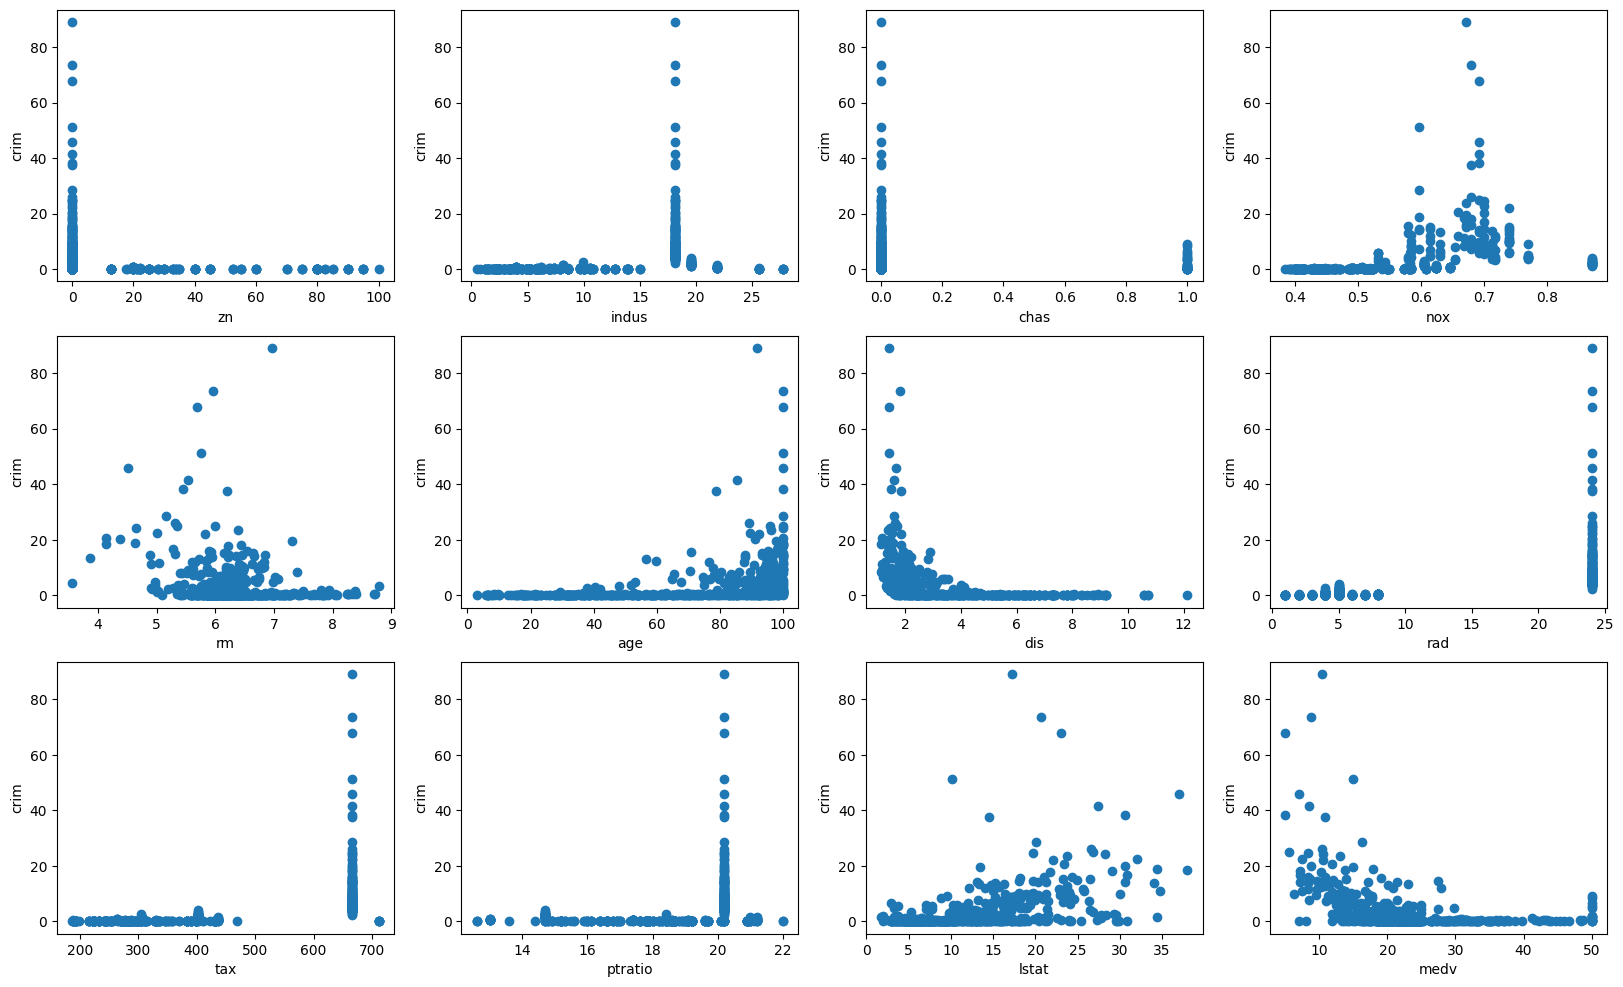

In [83]:
# So to do this, we cant call on the names of the vars as the TEMP_model or whatchacallit has been overwritten
# Ergo, we need to remodel the thingies, and in the same for loop, call each of the parameters.
# 15 a
X_terms = Boston.columns.drop('crim')
X_data = Boston[X_terms]

y = Boston[['crim']]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))
axes = axes.flatten()
j = 0
parameters_singular = [0]

for i in X_data:
    #X_temp = Boston[[X_data.columns[1]]]
    #X_temp = Boston[[i]]
    X_temp = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
    Boston[[i]]._info_axis[0]: Boston[i]})
    
    y = Boston[['crim']]
    model_temp = sm.OLS(y, X_temp)
    results_temp = model_temp.fit()
    parameters_singular.append(results_temp.params.iloc[1])
    print(summarize(results_temp))
    print('-------------------------------------')

    
    axes[j].scatter(Boston[i], y)
    axes[j].set_xlabel(i)
    axes[j].set_ylabel('crim')
    j = j+1
    print()

parameters_singular.pop(0)
parameters_singular

In [79]:
parameters_singular

[0,
 np.float64(-0.07393497740412368),
 np.float64(0.5097763311042306),
 np.float64(-1.892776550803758),
 np.float64(31.248531201122923),
 np.float64(-2.684051224113948),
 np.float64(0.1077862271395331),
 np.float64(-1.5509016824100994),
 np.float64(0.6179109273272014),
 np.float64(0.02974225282276537),
 np.float64(1.1519827870705872),
 np.float64(0.5488047820623981),
 np.float64(-0.363159922257603)]

In [84]:
parameters_multi = [0]

for i in results_15b.params:
    parameters_multi.append(i)

# Get rid of [0] starting thingy
parameters_multi.pop(0)

# Get rid of intercept (as we cant easily compare it)
parameters_multi.pop(0)

# Print out values to make sure they are goochie
parameters_multi

[0.045710038639755056,
 -0.05835011066598215,
 -0.8253775522410252,
 -9.957586547089177,
 0.6289106621782116,
 -0.000848279066190007,
 -1.0122467382083906,
 0.6124653114967955,
 -0.003775646523442281,
 -0.30407275723123517,
 0.13880059677676132,
 -0.2200563590392059]

Text(0, 0.5, 'Multiple Regression Coefficients')

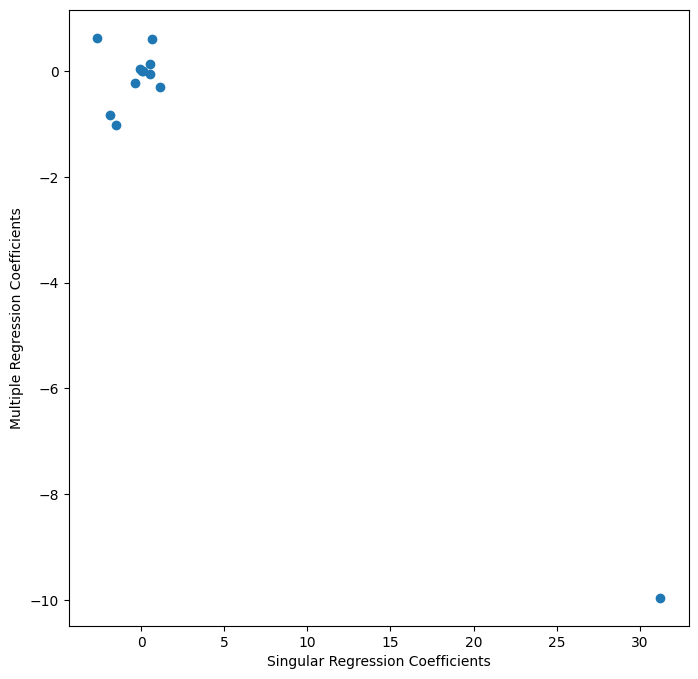

In [85]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(parameters_singular , parameters_multi)
ax.set_xlabel('Singular Regression Coefficients')
ax.set_ylabel('Multiple Regression Coefficients')

#### (d)

Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form

$\hspace{100pt} Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon$


                          coef  std err      t  P>|t|
intercept               3.6135    0.372  9.709  0.000
poly(zn, degree=3)[0] -38.7498    8.372 -4.628  0.000
poly(zn, degree=3)[1]  23.9398    8.372  2.859  0.004
poly(zn, degree=3)[2] -10.0719    8.372 -1.203  0.230
-------------------------------------
                             coef  std err       t  P>|t|
intercept                  3.6135    0.330  10.950  0.000
poly(indus, degree=3)[0]  78.5908    7.423  10.587  0.000
poly(indus, degree=3)[1] -24.3948    7.423  -3.286  0.001
poly(indus, degree=3)[2] -54.1298    7.423  -7.292  0.000
-------------------------------------
                                 coef       std err      t  P>|t|
intercept                9.971000e+12  2.100000e+13  0.475  0.635
poly(chas, degree=3)[0]  1.173000e+13  2.470000e+13  0.475  0.635
poly(chas, degree=3)[1]  1.249000e+14  2.630000e+14  0.475  0.635
poly(chas, degree=3)[2] -3.332000e+13  7.020000e+13 -0.475  0.635
----------------------------------

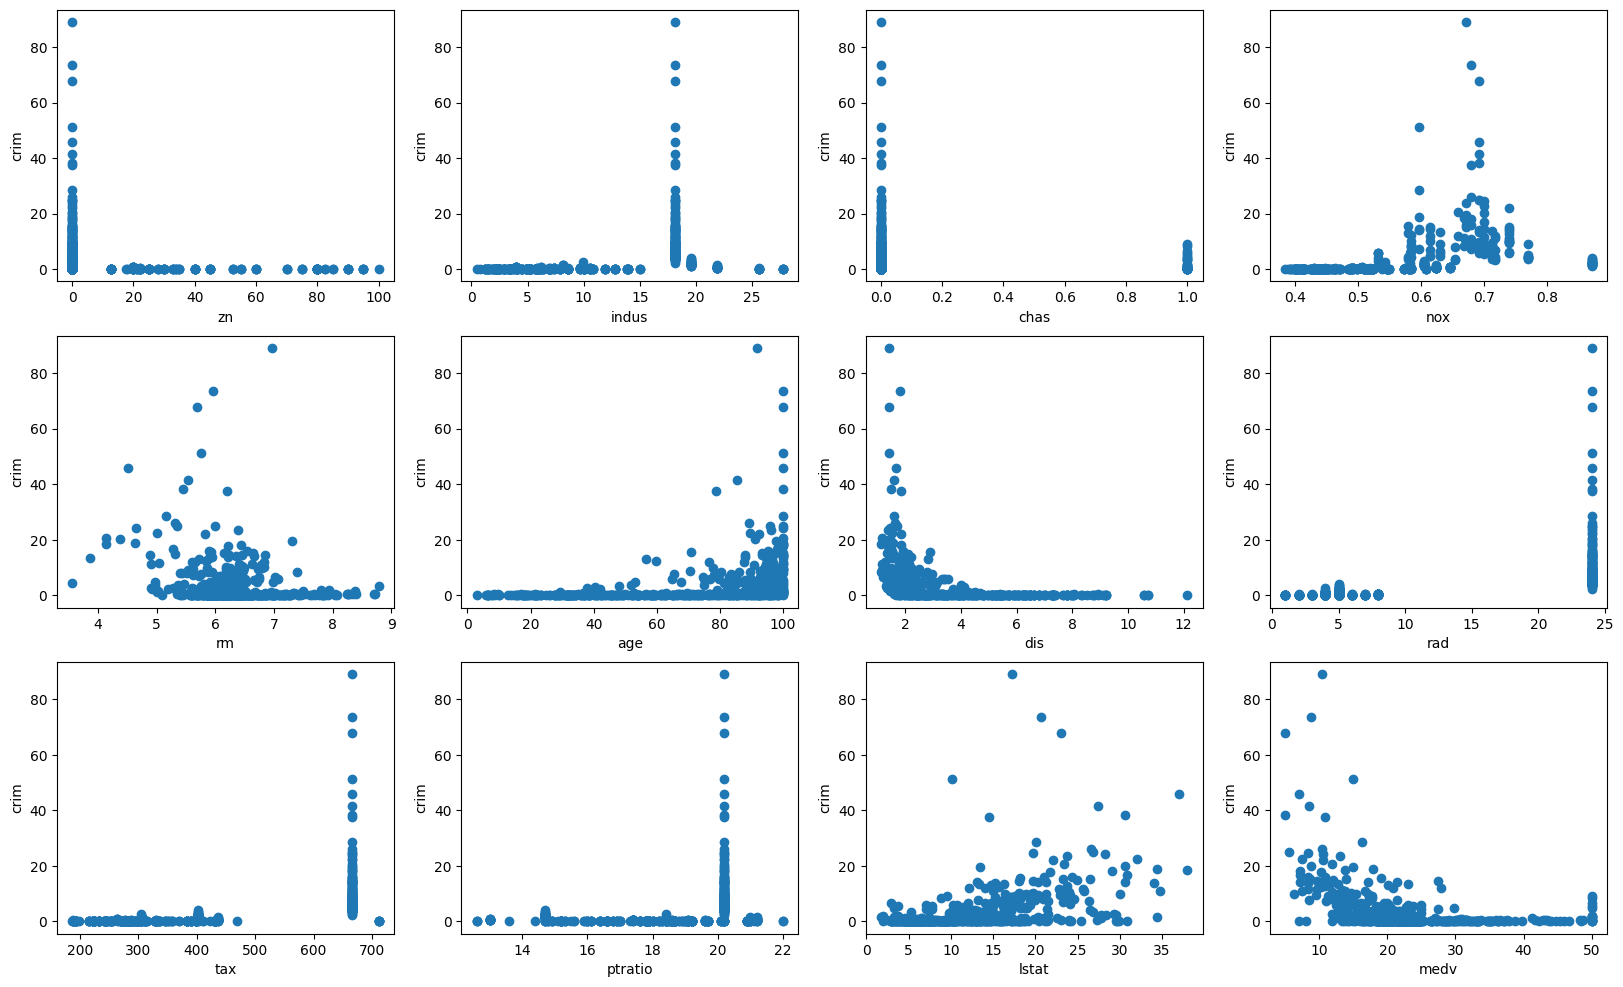

In [93]:
# Copying 15a, we remove some of the parameter saving thingies as we dont need to keep track of that any longer.

# Setup which elements we are looping, i.e. a list (?) of predictors we will iterate through.
X_terms = Boston.columns.drop('crim')
X_data = Boston[X_terms]

# Setup response.
y = Boston[['crim']]

# Setup for the graphs
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))
axes = axes.flatten()
j = 0
#parameters_singular = [0]

for i in X_data:
    # Makes the relevante dataframe for X. Note that we don't set Y, as its the same response for every loop element.
    #X_temp = pd.DataFrame({
    #    'intercept': np.ones(Boston.shape[0]),
    #    Boston[[i]]._info_axis[0]: Boston[i]
    #})
    
    X_temp = MS([poly(Boston[[i]]._info_axis[0], degree=3)]).fit_transform(Boston)

    
    # Models the data. Note that it overwrites previous parts of the loop, thats why we print out the results.
    model_temp = sm.OLS(y, X_temp)
    results_temp = model_temp.fit()
    
    # This part kept track of the variables on the previous question, we don't need this part any longer.
    #parameters_singular.append(results_temp.params.iloc[1])
    
    # Prints out the data for us to see
    print(summarize(results_temp))
    print('-------------------------------------')

    # This part is for plotting
    axes[j].scatter(Boston[i], y)
    axes[j].set_xlabel(i)
    axes[j].set_ylabel('crim')
    j = j+1

# This part got rid of the starting 0 value, then printed out the variables for me to check. No longer necessary
#parameters_singular.pop(0)
#parameters_singular
print('done')

